# Sugarcane_Production_Project

In [50]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [51]:
df = pd.read_csv('List of Countries by Sugarcane Production.csv')
df.head()

,Unnamed: 0,Country,Continent,Production (Tons),Production per Person (Kg),Acreage (Hectare),Yield (Kg / Hectare)
0,0,Brazil,South America,768.678.382,"3.668,531",10.226.205,"75.167,5"
1,1,India,Asia,348.448.000,260721,4.950.000,"70.393,5"
2,2,China,Asia,123.059.739,88287,1.675.215,"73.459,1"
3,3,Thailand,Asia,87.468.496,"1.264,303",1.336.575,"65.442,2"
4,4,Pakistan,Asia,65.450.704,324219,1.130.820,57.879


In [52]:
df.isnull().sum()

Unnamed: 0                    0
Country                       0
Continent                     0
Production (Tons)             0
Production per Person (Kg)    0
Acreage (Hectare)             1
Yield (Kg / Hectare)          1
dtype: int64

In [53]:
# Data Cleaning - Fix comma decimal formatting and handle missing values
def clean_numeric(x):
    if pd.isna(x) or x == '':
        return np.nan
    if isinstance(x, str):
        # Remove dots (thousands separator) and replace comma with dot (decimal separator)
        cleaned = x.replace('.', '').replace(',', '.')
        try:
            return float(cleaned)
        except:
            return np.nan
    return float(x)

# Apply cleaning to numeric columns
df['Production (Tons)'] = df['Production (Tons)'].apply(clean_numeric)
df['Production per Person (Kg)'] = df['Production per Person (Kg)'].apply(clean_numeric)
df['Acreage (Hectare)'] = df['Acreage (Hectare)'].apply(clean_numeric)
df['Yield (Kg / Hectare)'] = df['Yield (Kg / Hectare)'].apply(clean_numeric)

# Handle missing values - fill with median
print("Missing values before handling:")
print(df.isnull().sum())
print()

# Fill missing values with column median
df['Acreage (Hectare)'] = df['Acreage (Hectare)'].fillna(df['Acreage (Hectare)'].median())
df['Yield (Kg / Hectare)'] = df['Yield (Kg / Hectare)'].fillna(df['Yield (Kg / Hectare)'].median())

print("Missing values after handling:")
print(df.isnull().sum())
print()

print("✓ Data Cleaned Successfully!")
print("\nDataset Shape:", df.shape)
print("\nFirst Few Rows:")
df.head(10)

Missing values before handling:
Unnamed: 0                    0
Country                       0
Continent                     0
Production (Tons)             0
Production per Person (Kg)    0
Acreage (Hectare)             1
Yield (Kg / Hectare)          1
dtype: int64

Missing values after handling:
Unnamed: 0                    0
Country                       0
Continent                     0
Production (Tons)             0
Production per Person (Kg)    0
Acreage (Hectare)             0
Yield (Kg / Hectare)          0
dtype: int64

✓ Data Cleaned Successfully!

Dataset Shape: (103, 7)

First Few Rows:


,Unnamed: 0,Country,Continent,Production (Tons),Production per Person (Kg),Acreage (Hectare),Yield (Kg / Hectare)
0,0,Brazil,South America,768678382.0,3668.531,10226205.0,75167.5
1,1,India,Asia,348448000.0,260721.000,4950000.0,70393.5
2,2,China,Asia,123059739.0,88287.000,1675215.0,73459.1
3,3,Thailand,Asia,87468496.0,1264.303,1336575.0,65442.2
4,4,Pakistan,Asia,65450704.0,324219.000,1130820.0,57879.0
5,5,Mexico,North America,56446821.0,452524.000,781054.0,7227.0
6,6,Colombia,South America,36951213.0,740075.000,416626.0,88691.5
7,7,Australia,Oceania,34403004.0,1373.406,447204.0,76929.1
8,8,Guatemala,North America,33533403.0,1938.114,25985.0,129049.3
9,9,United States of America,North America,29926210.0,91304.000,37053.0,80766.0


In [54]:
# Dataset Information
print("="*80)
print("DATASET INFORMATION")
print("="*80)
print(f"\nTotal Countries: {len(df)}")
print(f"Total Continents: {df['Continent'].nunique()}")
print(f"\nContinents: {df['Continent'].unique().tolist()}")
print(f"\nData Types:\n{df.dtypes}")
print(f"\nMissing Values:\n{df.isnull().sum()}")

DATASET INFORMATION

Total Countries: 103
Total Continents: 6

Continents: ['South America', 'Asia', 'North America', 'Oceania', 'Africa', 'Europe']

Data Types:
Unnamed: 0                      int64
Country                        object
Continent                      object
Production (Tons)             float64
Production per Person (Kg)    float64
Acreage (Hectare)             float64
Yield (Kg / Hectare)          float64
dtype: object

Missing Values:
Unnamed: 0                    0
Country                       0
Continent                     0
Production (Tons)             0
Production per Person (Kg)    0
Acreage (Hectare)             0
Yield (Kg / Hectare)          0
dtype: int64


In [55]:
# Correlation Analysis
print("\n" + "="*80)
print("CORRELATION ANALYSIS")
print("="*80)
corr_columns = ['Production (Tons)', 'Production per Person (Kg)', 'Acreage (Hectare)', 'Yield (Kg / Hectare)']
correlation_matrix = df[corr_columns].corr()
print("\n", correlation_matrix.round(3))


CORRELATION ANALYSIS

                             Production (Tons)  Production per Person (Kg)  \
Production (Tons)                       1.000                       0.016   
Production per Person (Kg)              0.016                       1.000   
Acreage (Hectare)                       0.998                       0.014   
Yield (Kg / Hectare)                    0.133                       0.018   

                            Acreage (Hectare)  Yield (Kg / Hectare)  
Production (Tons)                       0.998                 0.133  
Production per Person (Kg)              0.014                 0.018  
Acreage (Hectare)                       1.000                 0.113  
Yield (Kg / Hectare)                    0.113                 1.000  


In [56]:
# Continental Analysis
print("\n" + "="*80)
print("CONTINENTAL ANALYSIS")
print("="*80)
continental_stats = df.groupby('Continent').agg({
    'Production (Tons)': ['sum', 'mean', 'count'],
    'Yield (Kg / Hectare)': 'mean',
    'Acreage (Hectare)': 'sum'
}).round(2)
continental_stats.columns = ['Total Production (Tons)', 'Avg Production (Tons)', 'No. of Countries', 'Avg Yield', 'Total Acreage']
print("\n", continental_stats.sort_values('Total Production (Tons)', ascending=False))


CONTINENTAL ANALYSIS

                Total Production (Tons)  Avg Production (Tons)  \
Continent                                                       
South America              865588126.0            78689829.64   
Asia                       721930425.0            28877217.00   
North America              173995947.0             7908906.68   
Africa                      89681525.0             2299526.28   
Oceania                     36177574.0             9044393.50   
Europe                          5823.0                2911.50   

               No. of Countries  Avg Yield  Total Acreage  
Continent                                                  
South America                11   61562.97     11369236.0  
Asia                         25   46874.86     10608319.0  
North America                22   49209.20      1581983.0  
Africa                       39   56313.24      1455647.0  
Oceania                       4   40604.78       490909.0  
Europe                        2   6

In [57]:
# Top 15 Countries by Production
print("\n" + "="*80)
print("TOP 15 COUNTRIES BY SUGARCANE PRODUCTION")
print("="*80)
top_15 = df.nlargest(15, 'Production (Tons)')[['Country', 'Continent', 'Production (Tons)', 'Yield (Kg / Hectare)']].reset_index(drop=True)
top_15.index = top_15.index + 1
print("\n", top_15)

# Bottom 10 Countries
print("\n" + "="*80)
print("BOTTOM 10 COUNTRIES BY SUGARCANE PRODUCTION")
print("="*80)
bottom_10 = df.nsmallest(10, 'Production (Tons)')[['Country', 'Continent', 'Production (Tons)', 'Yield (Kg / Hectare)']].reset_index(drop=True)
bottom_10.index = bottom_10.index + 1
print("\n", bottom_10)


TOP 15 COUNTRIES BY SUGARCANE PRODUCTION

                      Country      Continent  Production (Tons)  \
1                     Brazil  South America        768678382.0   
2                      India           Asia        348448000.0   
3                      China           Asia        123059739.0   
4                   Thailand           Asia         87468496.0   
5                   Pakistan           Asia         65450704.0   
6                     Mexico  North America         56446821.0   
7                   Colombia  South America         36951213.0   
8                  Australia        Oceania         34403004.0   
9                  Guatemala  North America         33533403.0   
10  United States of America  North America         29926210.0   
11                 Indonesia           Asia         27158830.0   
12               Philippines           Asia         22370546.0   
13                 Argentina  South America         21990823.0   
14                      Cuba  No

In [58]:
# Descriptive Statistics
print("\n" + "="*80)
print("DESCRIPTIVE STATISTICS")
print("="*80)
stats_df = df[['Production (Tons)', 'Production per Person (Kg)', 'Acreage (Hectare)', 'Yield (Kg / Hectare)']].describe()
print("\n", stats_df.round(2))


DESCRIPTIVE STATISTICS

        Production (Tons)  Production per Person (Kg)  Acreage (Hectare)  \
count       1.030000e+02                      103.00             103.00   
mean        1.832407e+07                   111856.31          247632.67   
std         8.379760e+07                   176134.93         1131649.72   
min         1.000000e+00                        0.00               0.00   
25%         4.298850e+04                     3364.87            1105.00   
50%         1.422432e+06                    25481.00           16558.00   
75%         6.145648e+06                   144004.50           80017.00   
max         7.686784e+08                   951087.00        10226205.00   

       Yield (Kg / Hectare)  
count                103.00  
mean               52642.46  
std                30355.13  
min                   10.00  
25%                29757.65  
50%                54108.95  
75%                73106.30  
max               129049.30  


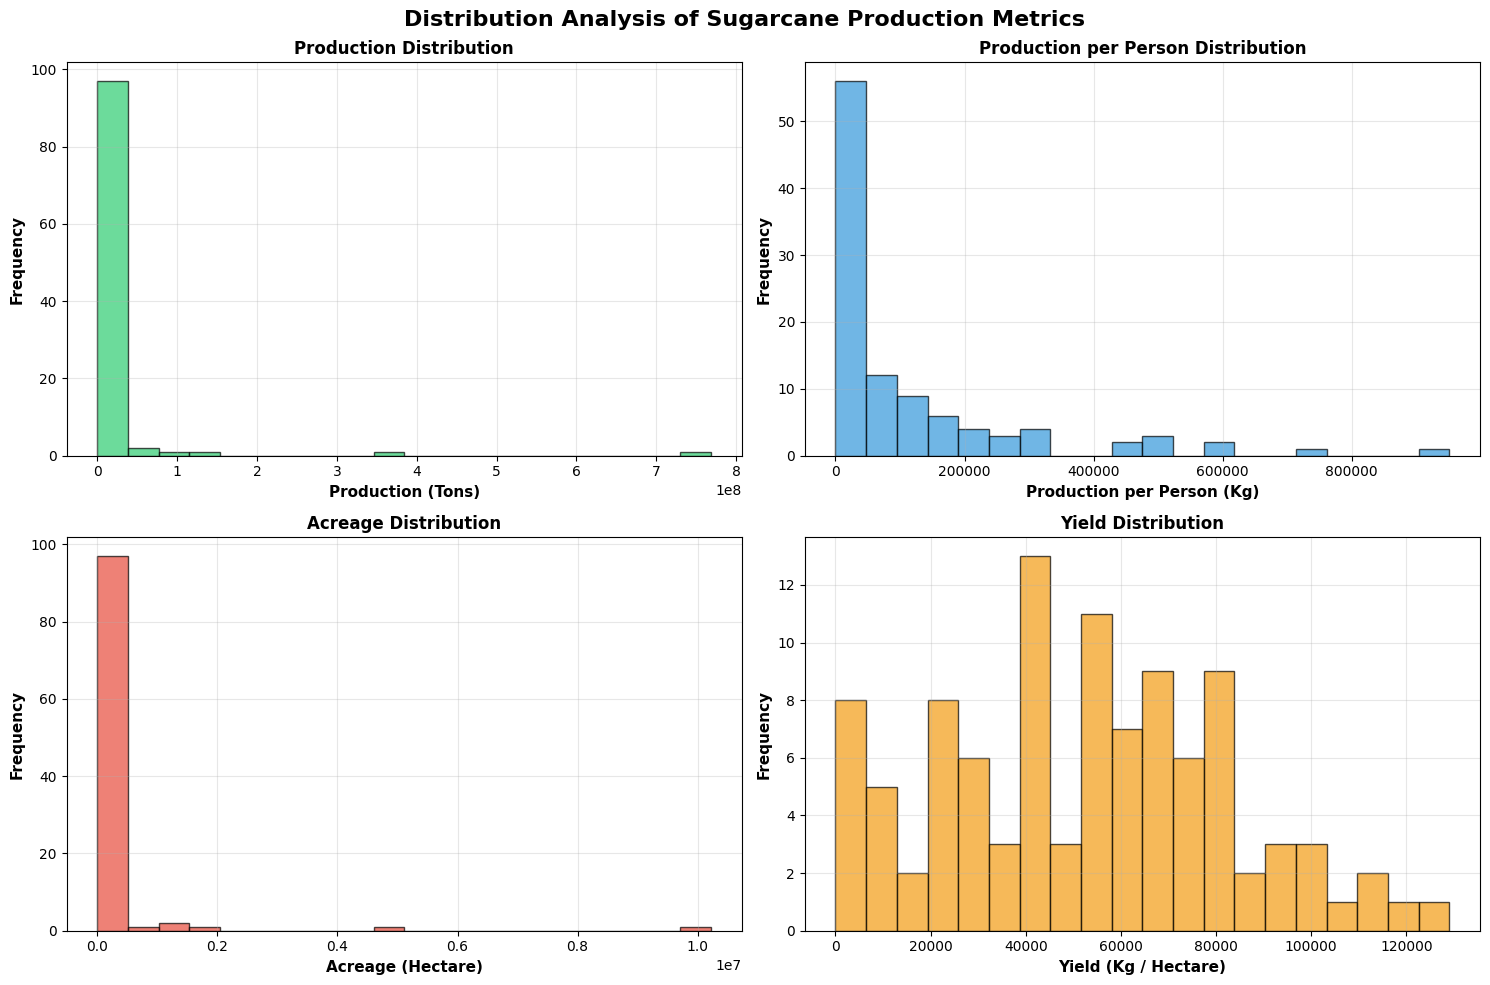

✓ Distribution histograms displayed


In [59]:
# Visualization 1: Distribution of Production
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('Distribution Analysis of Sugarcane Production Metrics', fontsize=16, fontweight='bold')

# Production Distribution
axes[0, 0].hist(df['Production (Tons)'], bins=20, color='#2ecc71', edgecolor='black', alpha=0.7)
axes[0, 0].set_xlabel('Production (Tons)', fontsize=11, fontweight='bold')
axes[0, 0].set_ylabel('Frequency', fontsize=11, fontweight='bold')
axes[0, 0].set_title('Production Distribution', fontsize=12, fontweight='bold')
axes[0, 0].grid(True, alpha=0.3)

# Production per Person
axes[0, 1].hist(df['Production per Person (Kg)'], bins=20, color='#3498db', edgecolor='black', alpha=0.7)
axes[0, 1].set_xlabel('Production per Person (Kg)', fontsize=11, fontweight='bold')
axes[0, 1].set_ylabel('Frequency', fontsize=11, fontweight='bold')
axes[0, 1].set_title('Production per Person Distribution', fontsize=12, fontweight='bold')
axes[0, 1].grid(True, alpha=0.3)

# Acreage
axes[1, 0].hist(df['Acreage (Hectare)'], bins=20, color='#e74c3c', edgecolor='black', alpha=0.7)
axes[1, 0].set_xlabel('Acreage (Hectare)', fontsize=11, fontweight='bold')
axes[1, 0].set_ylabel('Frequency', fontsize=11, fontweight='bold')
axes[1, 0].set_title('Acreage Distribution', fontsize=12, fontweight='bold')
axes[1, 0].grid(True, alpha=0.3)

# Yield
axes[1, 1].hist(df['Yield (Kg / Hectare)'], bins=20, color='#f39c12', edgecolor='black', alpha=0.7)
axes[1, 1].set_xlabel('Yield (Kg / Hectare)', fontsize=11, fontweight='bold')
axes[1, 1].set_ylabel('Frequency', fontsize=11, fontweight='bold')
axes[1, 1].set_title('Yield Distribution', fontsize=12, fontweight='bold')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
print("✓ Distribution histograms displayed")

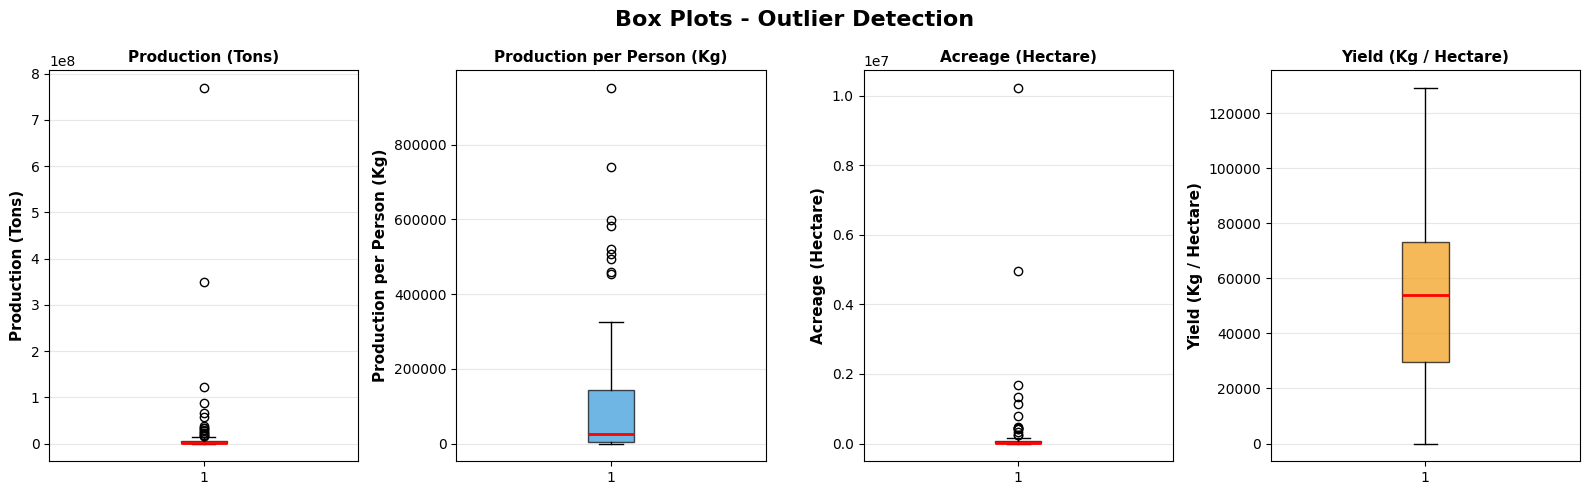

✓ Box plots displayed


In [60]:
# Visualization 2: Box Plots for Outlier Detection
fig, axes = plt.subplots(1, 4, figsize=(16, 5))
fig.suptitle('Box Plots - Outlier Detection', fontsize=16, fontweight='bold')

metrics = ['Production (Tons)', 'Production per Person (Kg)', 'Acreage (Hectare)', 'Yield (Kg / Hectare)']
colors = ['#2ecc71', '#3498db', '#e74c3c', '#f39c12']

for idx, (ax, metric, color) in enumerate(zip(axes, metrics, colors)):
    ax.boxplot(df[metric], vert=True, patch_artist=True, 
               boxprops=dict(facecolor=color, alpha=0.7),
               medianprops=dict(color='red', linewidth=2))
    ax.set_ylabel(metric, fontsize=11, fontweight='bold')
    ax.set_title(f'{metric}', fontsize=11, fontweight='bold')
    ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()
print("✓ Box plots displayed")

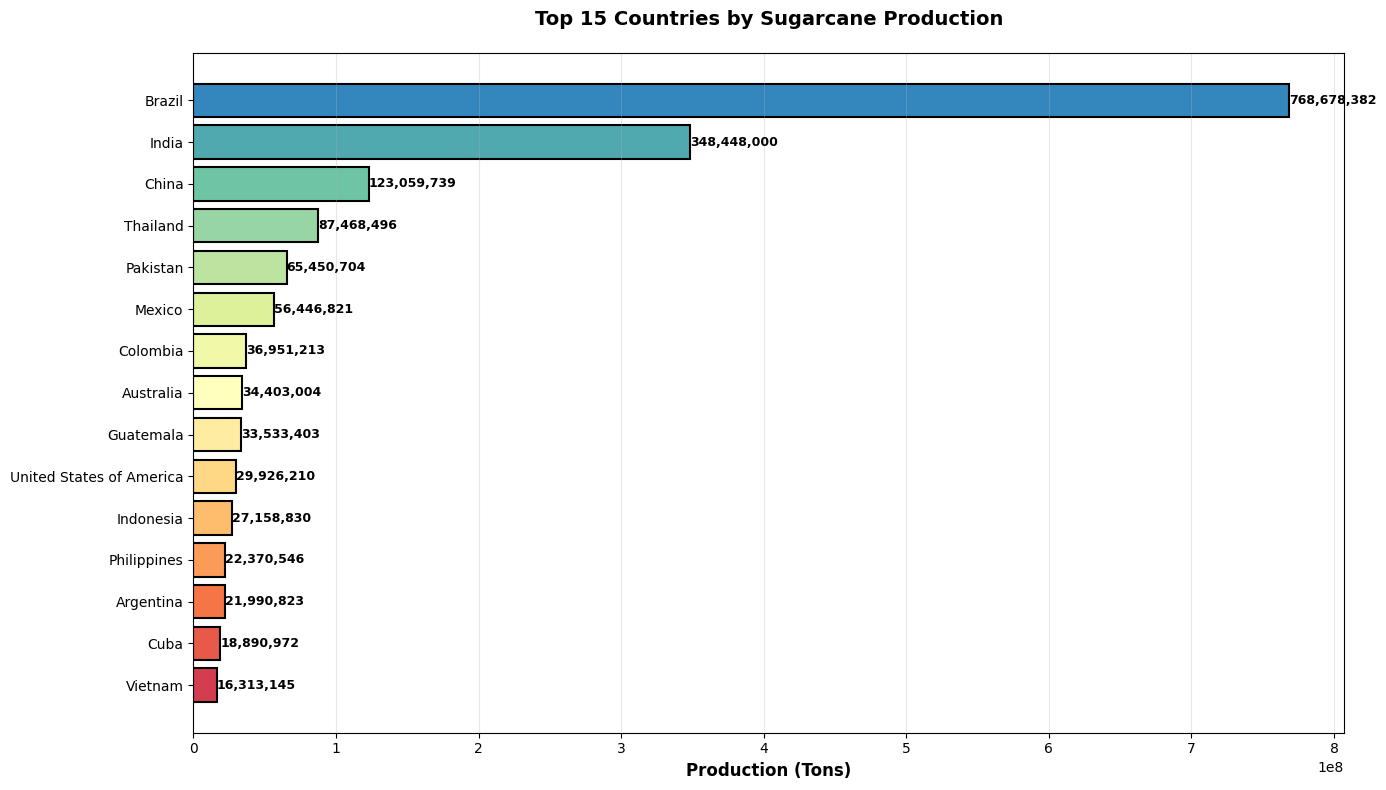

✓ Top 15 countries bar chart displayed


In [61]:
# Visualization 3: Top 15 Countries by Production
fig, ax = plt.subplots(figsize=(14, 8))
top_countries = df.nlargest(15, 'Production (Tons)').sort_values('Production (Tons)')

bars = ax.barh(top_countries['Country'], top_countries['Production (Tons)'], 
               color=plt.cm.Spectral(np.linspace(0.1, 0.9, len(top_countries))), 
               edgecolor='black', linewidth=1.5)

ax.set_xlabel('Production (Tons)', fontsize=12, fontweight='bold')
ax.set_title('Top 15 Countries by Sugarcane Production', fontsize=14, fontweight='bold', pad=20)
ax.grid(True, alpha=0.3, axis='x')

# Add value labels
for i, bar in enumerate(bars):
    width = bar.get_width()
    ax.text(width, bar.get_y() + bar.get_height()/2, 
            f'{width:,.0f}', 
            ha='left', va='center', fontweight='bold', fontsize=9)

plt.tight_layout()
plt.show()
print("✓ Top 15 countries bar chart displayed")

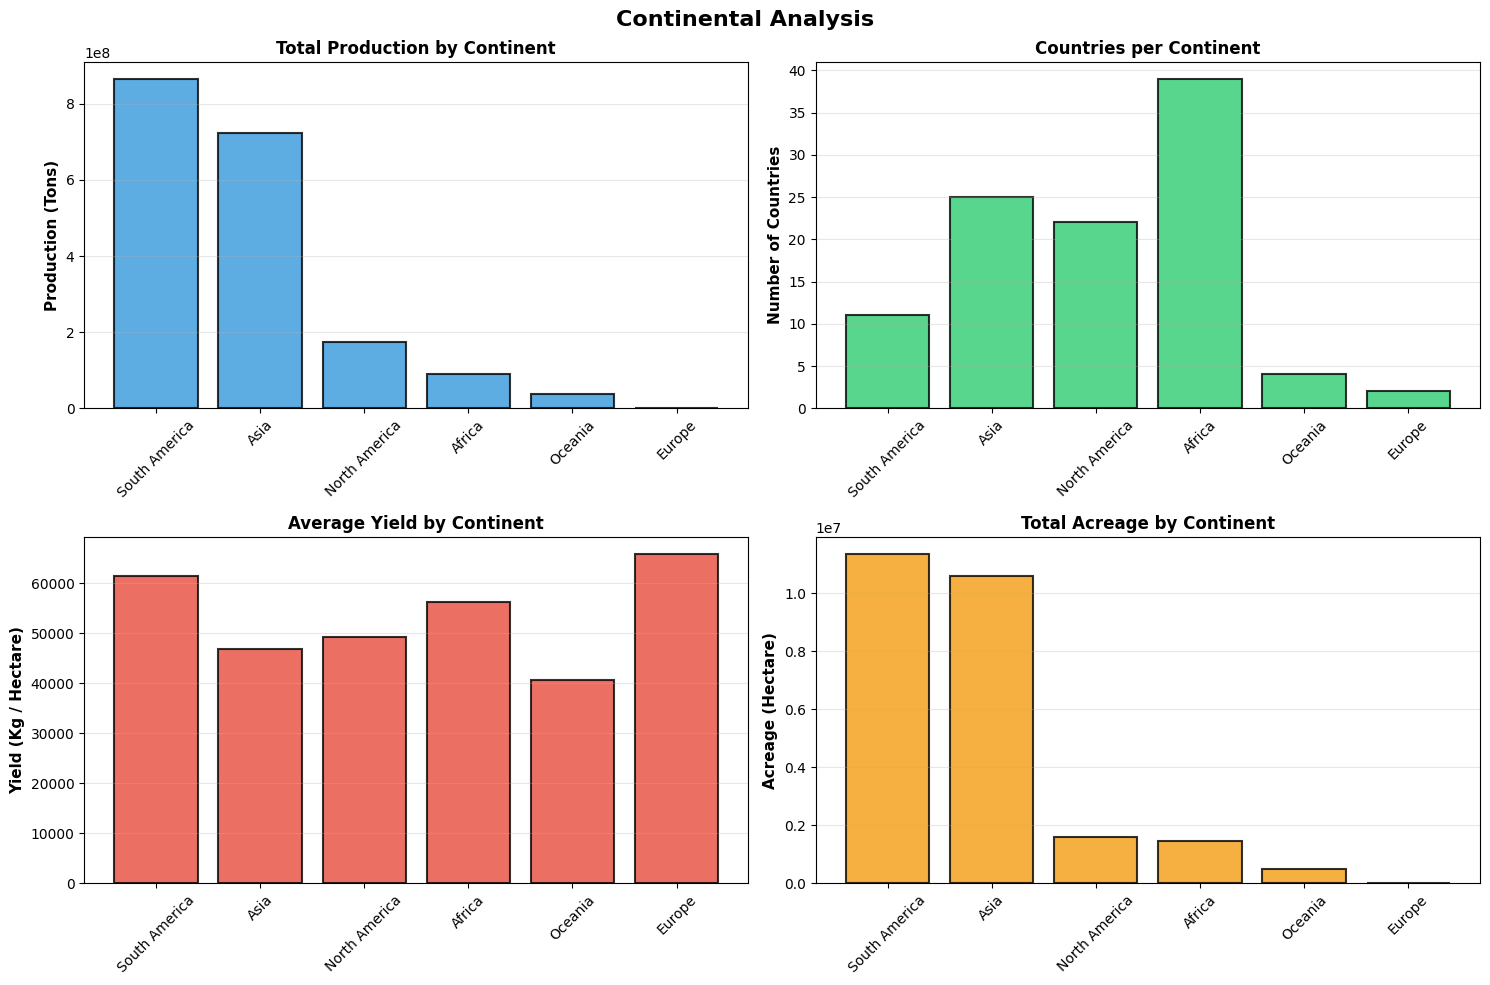

✓ Continental analysis charts displayed


In [62]:
# Visualization 4: Continental Comparison
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('Continental Analysis', fontsize=16, fontweight='bold')

continental_data = df.groupby('Continent').agg({
    'Production (Tons)': 'sum',
    'Country': 'count',
    'Yield (Kg / Hectare)': 'mean',
    'Acreage (Hectare)': 'sum'
}).sort_values('Production (Tons)', ascending=False)

# Total Production by Continent
axes[0, 0].bar(continental_data.index, continental_data['Production (Tons)'], 
               color='#3498db', edgecolor='black', linewidth=1.5, alpha=0.8)
axes[0, 0].set_ylabel('Production (Tons)', fontsize=11, fontweight='bold')
axes[0, 0].set_title('Total Production by Continent', fontsize=12, fontweight='bold')
axes[0, 0].tick_params(axis='x', rotation=45)
axes[0, 0].grid(True, alpha=0.3, axis='y')

# Number of Countries
axes[0, 1].bar(continental_data.index, continental_data['Country'], 
               color='#2ecc71', edgecolor='black', linewidth=1.5, alpha=0.8)
axes[0, 1].set_ylabel('Number of Countries', fontsize=11, fontweight='bold')
axes[0, 1].set_title('Countries per Continent', fontsize=12, fontweight='bold')
axes[0, 1].tick_params(axis='x', rotation=45)
axes[0, 1].grid(True, alpha=0.3, axis='y')

# Average Yield by Continent
axes[1, 0].bar(continental_data.index, continental_data['Yield (Kg / Hectare)'], 
               color='#e74c3c', edgecolor='black', linewidth=1.5, alpha=0.8)
axes[1, 0].set_ylabel('Yield (Kg / Hectare)', fontsize=11, fontweight='bold')
axes[1, 0].set_title('Average Yield by Continent', fontsize=12, fontweight='bold')
axes[1, 0].tick_params(axis='x', rotation=45)
axes[1, 0].grid(True, alpha=0.3, axis='y')

# Total Acreage
axes[1, 1].bar(continental_data.index, continental_data['Acreage (Hectare)'], 
               color='#f39c12', edgecolor='black', linewidth=1.5, alpha=0.8)
axes[1, 1].set_ylabel('Acreage (Hectare)', fontsize=11, fontweight='bold')
axes[1, 1].set_title('Total Acreage by Continent', fontsize=12, fontweight='bold')
axes[1, 1].tick_params(axis='x', rotation=45)
axes[1, 1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()
print("✓ Continental analysis charts displayed")

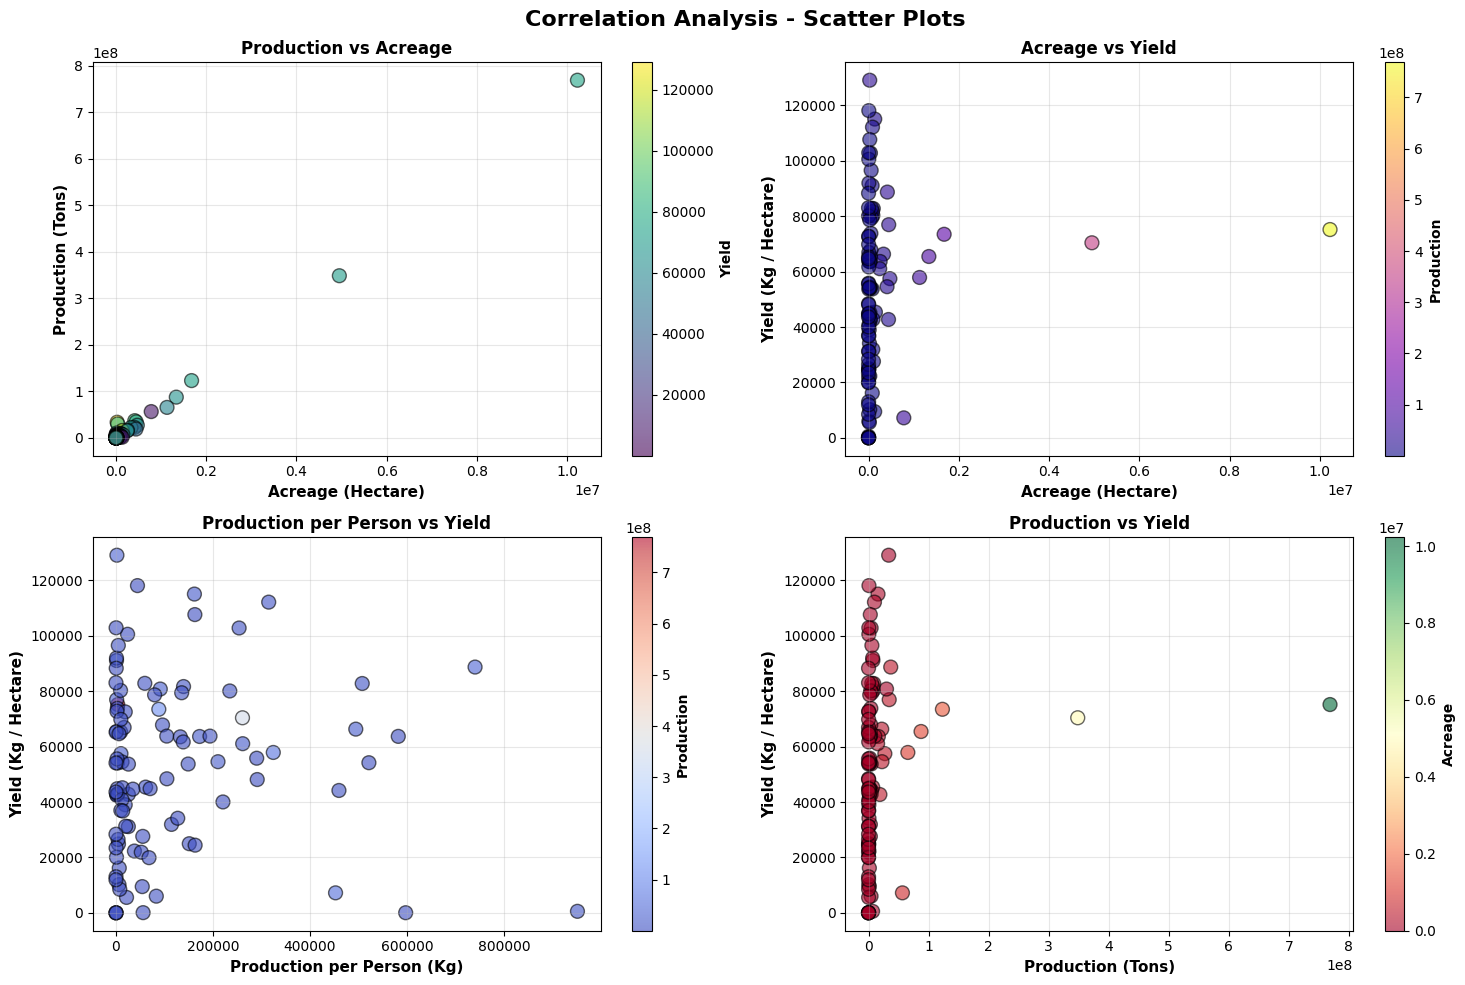

✓ Correlation scatter plots displayed


In [63]:
# Visualization 5: Scatter Plots - Correlations
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('Correlation Analysis - Scatter Plots', fontsize=16, fontweight='bold')

# Production vs Acreage
scatter1 = axes[0, 0].scatter(df['Acreage (Hectare)'], df['Production (Tons)'], 
                              c=df['Yield (Kg / Hectare)'], cmap='viridis', s=100, alpha=0.6, edgecolor='black')
axes[0, 0].set_xlabel('Acreage (Hectare)', fontsize=11, fontweight='bold')
axes[0, 0].set_ylabel('Production (Tons)', fontsize=11, fontweight='bold')
axes[0, 0].set_title('Production vs Acreage', fontsize=12, fontweight='bold')
axes[0, 0].grid(True, alpha=0.3)
cbar1 = plt.colorbar(scatter1, ax=axes[0, 0])
cbar1.set_label('Yield', fontweight='bold')

# Acreage vs Yield
scatter2 = axes[0, 1].scatter(df['Acreage (Hectare)'], df['Yield (Kg / Hectare)'], 
                              c=df['Production (Tons)'], cmap='plasma', s=100, alpha=0.6, edgecolor='black')
axes[0, 1].set_xlabel('Acreage (Hectare)', fontsize=11, fontweight='bold')
axes[0, 1].set_ylabel('Yield (Kg / Hectare)', fontsize=11, fontweight='bold')
axes[0, 1].set_title('Acreage vs Yield', fontsize=12, fontweight='bold')
axes[0, 1].grid(True, alpha=0.3)
cbar2 = plt.colorbar(scatter2, ax=axes[0, 1])
cbar2.set_label('Production', fontweight='bold')

# Production per Person vs Yield
scatter3 = axes[1, 0].scatter(df['Production per Person (Kg)'], df['Yield (Kg / Hectare)'], 
                              c=df['Production (Tons)'], cmap='coolwarm', s=100, alpha=0.6, edgecolor='black')
axes[1, 0].set_xlabel('Production per Person (Kg)', fontsize=11, fontweight='bold')
axes[1, 0].set_ylabel('Yield (Kg / Hectare)', fontsize=11, fontweight='bold')
axes[1, 0].set_title('Production per Person vs Yield', fontsize=12, fontweight='bold')
axes[1, 0].grid(True, alpha=0.3)
cbar3 = plt.colorbar(scatter3, ax=axes[1, 0])
cbar3.set_label('Production', fontweight='bold')

# Production vs Yield
scatter4 = axes[1, 1].scatter(df['Production (Tons)'], df['Yield (Kg / Hectare)'], 
                              c=df['Acreage (Hectare)'], cmap='RdYlGn', s=100, alpha=0.6, edgecolor='black')
axes[1, 1].set_xlabel('Production (Tons)', fontsize=11, fontweight='bold')
axes[1, 1].set_ylabel('Yield (Kg / Hectare)', fontsize=11, fontweight='bold')
axes[1, 1].set_title('Production vs Yield', fontsize=12, fontweight='bold')
axes[1, 1].grid(True, alpha=0.3)
cbar4 = plt.colorbar(scatter4, ax=axes[1, 1])
cbar4.set_label('Acreage', fontweight='bold')

plt.tight_layout()
plt.show()
print("✓ Correlation scatter plots displayed")

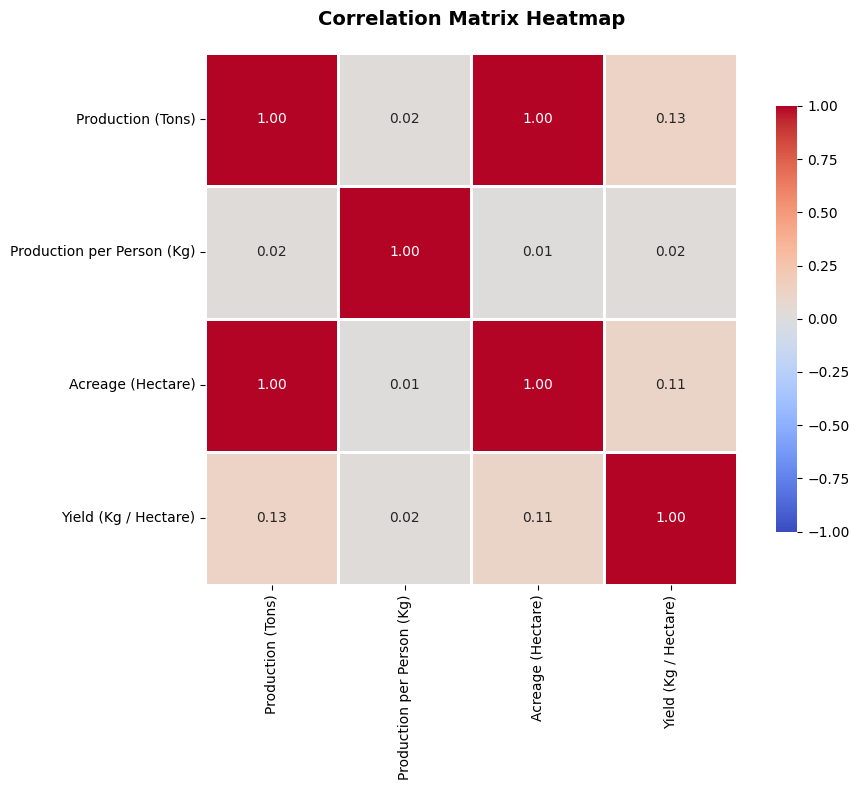

✓ Correlation heatmap displayed


In [64]:
# Visualization 6: Heatmap - Correlation Matrix
fig, ax = plt.subplots(figsize=(10, 8))

corr_cols = ['Production (Tons)', 'Production per Person (Kg)', 'Acreage (Hectare)', 'Yield (Kg / Hectare)']
correlation = df[corr_cols].corr()

sns.heatmap(correlation, annot=True, cmap='coolwarm', center=0, 
            square=True, linewidths=1, cbar_kws={"shrink": 0.8}, 
            fmt='.2f', ax=ax, vmin=-1, vmax=1)

ax.set_title('Correlation Matrix Heatmap', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()
print("✓ Correlation heatmap displayed")

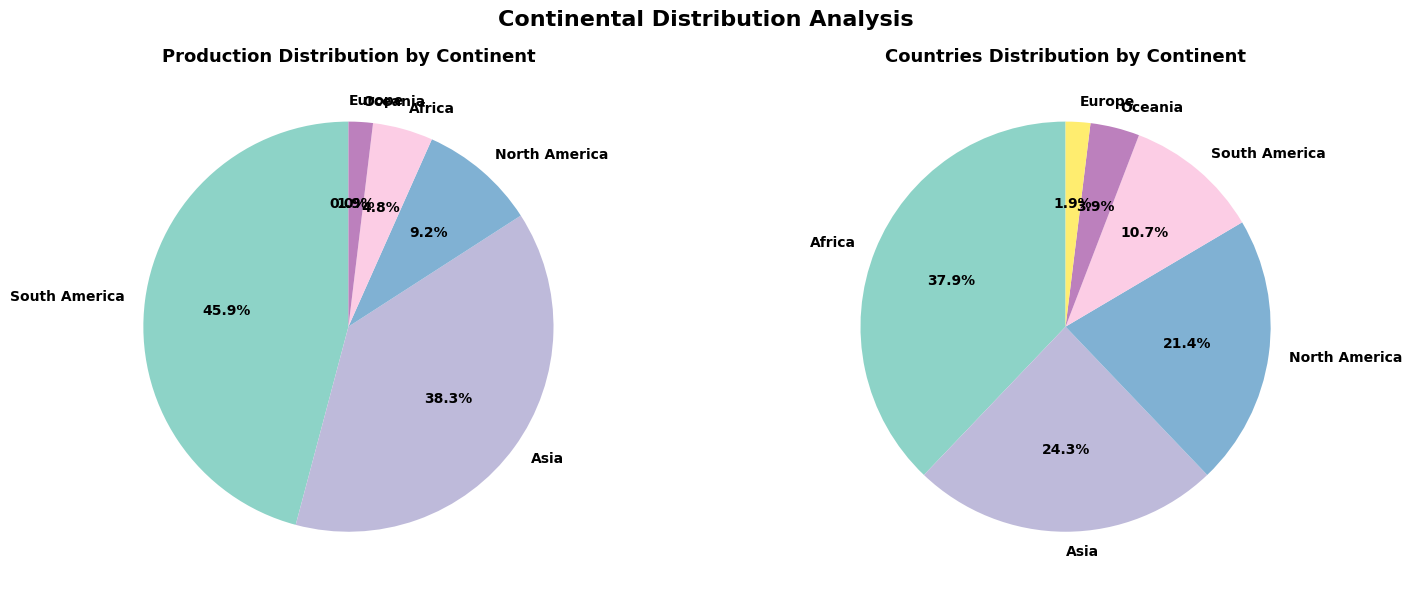

✓ Pie charts displayed


In [65]:
# Visualization 7: Pie Charts - Continental Distribution
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Continental Distribution Analysis', fontsize=16, fontweight='bold')

continental_prod = df.groupby('Continent')['Production (Tons)'].sum().sort_values(ascending=False)
continental_count = df.groupby('Continent')['Country'].count().sort_values(ascending=False)

colors_palette = plt.cm.Set3(np.linspace(0, 1, len(continental_prod)))

# Production Distribution
wedges1, texts1, autotexts1 = axes[0].pie(continental_prod, labels=continental_prod.index, 
                                           autopct='%1.1f%%', startangle=90, colors=colors_palette,
                                           textprops={'fontweight': 'bold', 'fontsize': 10})
axes[0].set_title('Production Distribution by Continent', fontsize=13, fontweight='bold')

# Countries Distribution
wedges2, texts2, autotexts2 = axes[1].pie(continental_count, labels=continental_count.index, 
                                           autopct='%1.1f%%', startangle=90, colors=colors_palette,
                                           textprops={'fontweight': 'bold', 'fontsize': 10})
axes[1].set_title('Countries Distribution by Continent', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()
print("✓ Pie charts displayed")

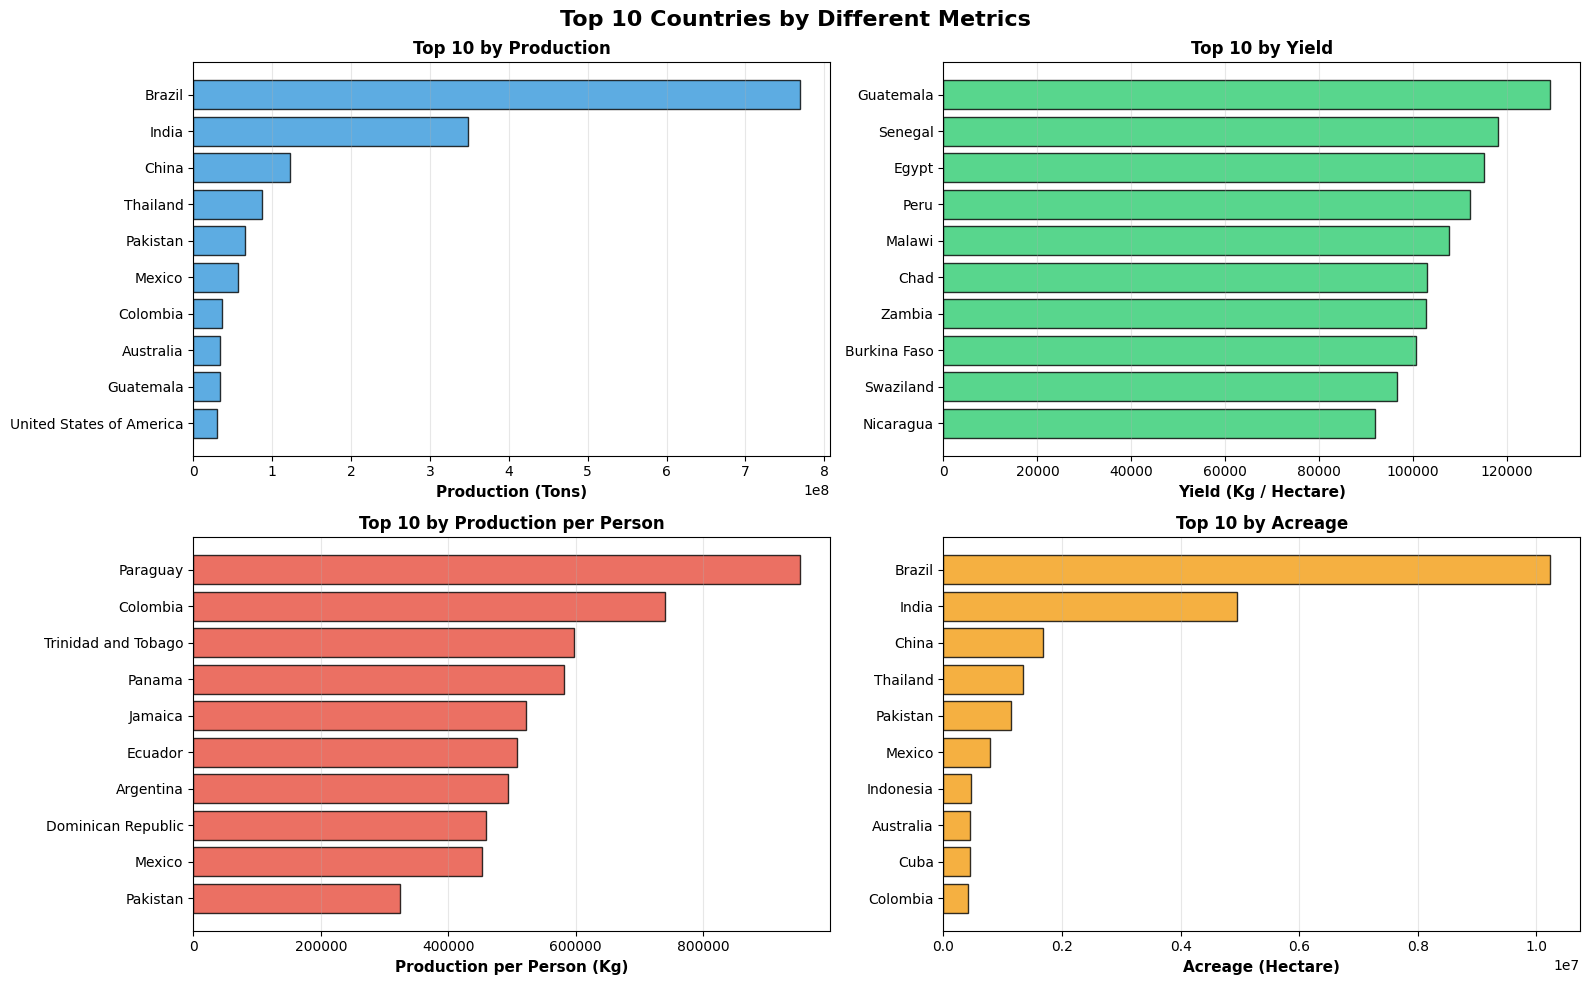

✓ Top countries by different metrics displayed


In [66]:
# Visualization 8: Top Countries by Different Metrics
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Top 10 Countries by Different Metrics', fontsize=16, fontweight='bold')

# Top by Production
top_prod = df.nlargest(10, 'Production (Tons)').sort_values('Production (Tons)')
axes[0, 0].barh(top_prod['Country'], top_prod['Production (Tons)'], 
                color='#3498db', edgecolor='black', alpha=0.8)
axes[0, 0].set_xlabel('Production (Tons)', fontsize=11, fontweight='bold')
axes[0, 0].set_title('Top 10 by Production', fontsize=12, fontweight='bold')
axes[0, 0].grid(True, alpha=0.3, axis='x')

# Top by Yield
top_yield = df.nlargest(10, 'Yield (Kg / Hectare)').sort_values('Yield (Kg / Hectare)')
axes[0, 1].barh(top_yield['Country'], top_yield['Yield (Kg / Hectare)'], 
                color='#2ecc71', edgecolor='black', alpha=0.8)
axes[0, 1].set_xlabel('Yield (Kg / Hectare)', fontsize=11, fontweight='bold')
axes[0, 1].set_title('Top 10 by Yield', fontsize=12, fontweight='bold')
axes[0, 1].grid(True, alpha=0.3, axis='x')

# Top by Production per Person
top_per_person = df.nlargest(10, 'Production per Person (Kg)').sort_values('Production per Person (Kg)')
axes[1, 0].barh(top_per_person['Country'], top_per_person['Production per Person (Kg)'], 
                color='#e74c3c', edgecolor='black', alpha=0.8)
axes[1, 0].set_xlabel('Production per Person (Kg)', fontsize=11, fontweight='bold')
axes[1, 0].set_title('Top 10 by Production per Person', fontsize=12, fontweight='bold')
axes[1, 0].grid(True, alpha=0.3, axis='x')

# Top by Acreage
top_acreage = df.nlargest(10, 'Acreage (Hectare)').sort_values('Acreage (Hectare)')
axes[1, 1].barh(top_acreage['Country'], top_acreage['Acreage (Hectare)'], 
                color='#f39c12', edgecolor='black', alpha=0.8)
axes[1, 1].set_xlabel('Acreage (Hectare)', fontsize=11, fontweight='bold')
axes[1, 1].set_title('Top 10 by Acreage', fontsize=12, fontweight='bold')
axes[1, 1].grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()
print("✓ Top countries by different metrics displayed")

In [67]:
# Summary Statistics and Key Insights
print("\n" + "="*80)
print("KEY INSIGHTS & SUMMARY")
print("="*80)

print("\n📊 PRODUCTION INSIGHTS:")
if df['Production (Tons)'].notna().any():
    max_idx = df['Production (Tons)'].idxmax()
    min_idx = df['Production (Tons)'].idxmin()
    print(f"   • Highest Production: {df.loc[max_idx, 'Country']} ({df.loc[max_idx, 'Production (Tons)']:,.0f} Tons)")
    print(f"   • Lowest Production: {df.loc[min_idx, 'Country']} ({df.loc[min_idx, 'Production (Tons)']:,.0f} Tons)")
    print(f"   • Average Production: {df['Production (Tons)'].mean():,.0f} Tons")
    print(f"   • Median Production: {df['Production (Tons)'].median():,.0f} Tons")
    print(f"   • Total Global Production: {df['Production (Tons)'].sum():,.0f} Tons")

print("\n🌾 YIELD INSIGHTS:")
if df['Yield (Kg / Hectare)'].notna().any():
    max_idx = df['Yield (Kg / Hectare)'].idxmax()
    min_idx = df['Yield (Kg / Hectare)'].idxmin()
    print(f"   • Highest Yield: {df.loc[max_idx, 'Country']} ({df.loc[max_idx, 'Yield (Kg / Hectare)']:,.2f} Kg/Ha)")
    print(f"   • Lowest Yield: {df.loc[min_idx, 'Country']} ({df.loc[min_idx, 'Yield (Kg / Hectare)']:,.2f} Kg/Ha)")
    print(f"   • Average Yield: {df['Yield (Kg / Hectare)'].mean():,.2f} Kg/Ha")
    print(f"   • Yield Range: {df['Yield (Kg / Hectare)'].max() - df['Yield (Kg / Hectare)'].min():,.2f} Kg/Ha")

print("\n👥 PRODUCTION PER PERSON:")
if df['Production per Person (Kg)'].notna().any():
    max_idx = df['Production per Person (Kg)'].idxmax()
    print(f"   • Highest: {df.loc[max_idx, 'Country']} ({df.loc[max_idx, 'Production per Person (Kg)']:,.0f} Kg/Person)")
    print(f"   • Average: {df['Production per Person (Kg)'].mean():,.0f} Kg/Person")

print("\n📍 CONTINENTAL LEADERS:")
for continent in df['Continent'].unique():
    continent_data = df[df['Continent'] == continent]
    if len(continent_data) > 0 and continent_data['Production (Tons)'].notna().any():
        top_idx = continent_data['Production (Tons)'].idxmax()
        top_country = df.loc[top_idx]
        print(f"   • {continent}: {top_country['Country']} ({top_country['Production (Tons)']:,.0f} Tons)")

print("\n" + "="*80)


KEY INSIGHTS & SUMMARY

📊 PRODUCTION INSIGHTS:
   • Highest Production: Brazil (768,678,382 Tons)
   • Lowest Production: Syria (1 Tons)
   • Average Production: 18,324,072 Tons
   • Median Production: 1,422,432 Tons
   • Total Global Production: 1,887,379,420 Tons

🌾 YIELD INSIGHTS:
   • Highest Yield: Guatemala (129,049.30 Kg/Ha)
   • Lowest Yield: Yemen (10.00 Kg/Ha)
   • Average Yield: 52,642.46 Kg/Ha
   • Yield Range: 129,039.30 Kg/Ha

👥 PRODUCTION PER PERSON:
   • Highest: Paraguay (951,087 Kg/Person)
   • Average: 111,856 Kg/Person

📍 CONTINENTAL LEADERS:
   • South America: Brazil (768,678,382 Tons)
   • Asia: India (348,448,000 Tons)
   • North America: Mexico (56,446,821 Tons)
   • Oceania: Australia (34,403,004 Tons)
   • Africa: Egypt (15,760,418 Tons)
   • Europe: Portugal (5,429 Tons)

